In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define the ticker and timeframe
ticker = "^GSPC" # S&P 500 Index
start_date = "2020-01-01"
end_date = datetime.now().strftime('%Y-%m-%d')

# Download data
df = yf.download(ticker, start=start_date, end=end_date)
df.reset_index(inplace=True)

print(f"Successfully downloaded {len(df)} rows of data.")

/tmp/ipykernel_3740/2966258779.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Successfully downloaded 1593 rows of data.


In [4]:
# Calculate 50-day and 200-day Moving Averages (Golden/Death Cross indicators)
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Daily Returns (Percentage Change)
df['Daily_Return'] = df['Close'].pct_change()

# Volatility (30-day rolling standard deviation of returns)
df['Volatility'] = df['Daily_Return'].rolling(window=30).std() * np.sqrt(252)

df.tail()

Price,Date,Close,High,Low,Open,Volume,MA50,MA200,Daily_Return,Volatility
Ticker,,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,,,,
1588,2026-04-29,7135.950195,7145.629883,7107.859863,7131.609863,5123100000,6807.995410,6718.786992,-0.000399,0.171231
1589,2026-04-30,7209.009766,7219.830078,7126.149902,7161.750000,5723790000,6814.549404,6723.613242,0.010238,0.166119
1590,2026-05-01,7230.120117,7272.520020,7229.319824,7234.540039,4847390000,6821.914004,6728.445342,0.002928,0.165262
1591,2026-05-04,7200.750000,7244.540039,7174.120117,7228.379883,5215480000,6827.738809,6732.962292,-0.004062,0.157602
1592,2026-05-05,7259.220215,7273.259766,7233.620117,7233.620117,5279760000,6836.168213,6737.774443,0.008120,0.156419


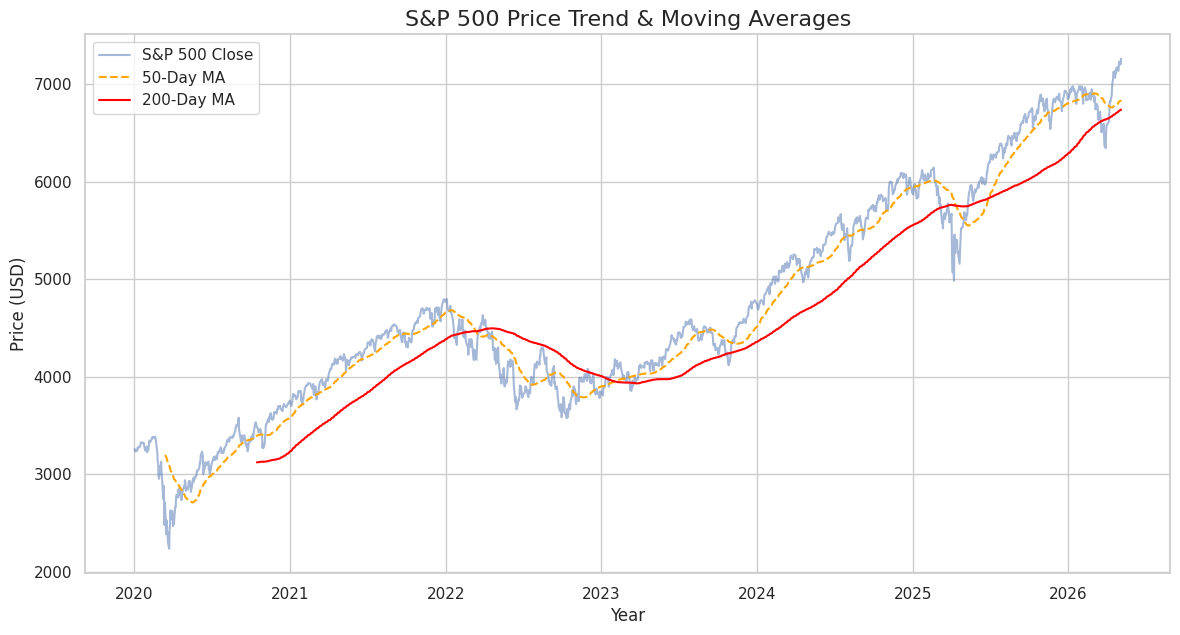

In [5]:
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], label='S&P 500 Close', alpha=0.5)
plt.plot(df['Date'], df['MA50'], label='50-Day MA', color='orange', linestyle='--')
plt.plot(df['Date'], df['MA200'], label='200-Day MA', color='red')

plt.title('S&P 500 Price Trend & Moving Averages', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

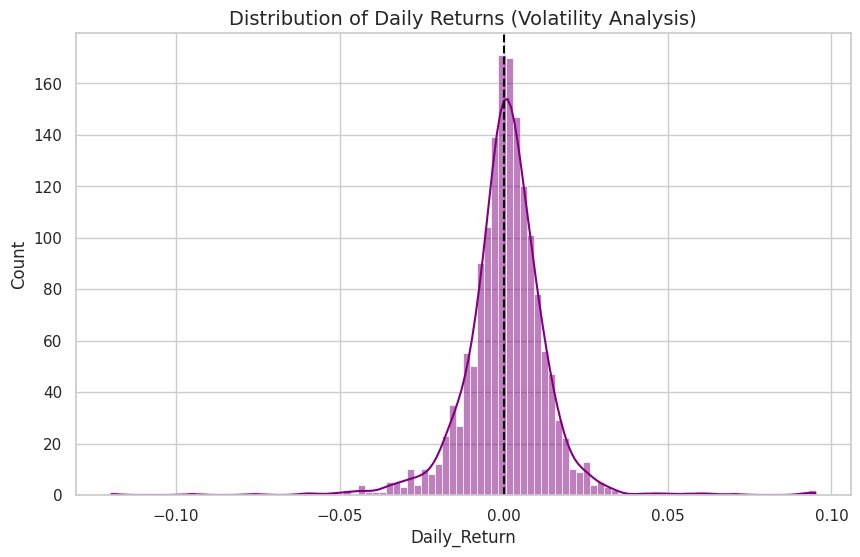

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Return'].dropna(), kde=True, color='purple', bins=100)
plt.title('Distribution of Daily Returns (Volatility Analysis)', fontsize=14)
plt.axvline(0, color='black', linestyle='--') # Zero return line
plt.show()

/tmp/ipykernel_3740/2571670250.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  comp_data = yf.download(tickers, start="2023-01-01")['Close']
[*********************100%***********************]  4 of 4 completed
/tmp/ipykernel_3740/2571670250.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  corr = comp_data.pct_change().corr()


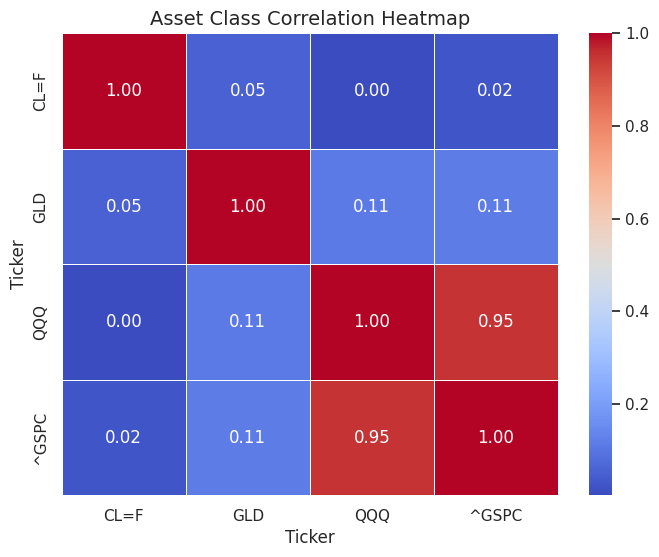

In [7]:
# Fetch comparison tickers
tickers = ["^GSPC", "QQQ", "GLD", "CL=F"] # S&P, Nasdaq, Gold, Oil
comp_data = yf.download(tickers, start="2023-01-01")['Close']

# Calculate correlation matrix
corr = comp_data.pct_change().corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Asset Class Correlation Heatmap', fontsize=14)
plt.show()